# Reporte Ejecutivo de Retención de Talento: Proyecto Salifort

Este reporte presenta los resultados del análisis y modelado predictivo para la retención de empleados en Salifort Motors. El objetivo principal es identificar qué factores causan la rotación del personal y construir un modelo predictivo altamente de confianza para identificar empleados en riesgo de abandono.

---

## 1. Contexto del Negocio y Objetivos

La pérdida de talento clave (employee churn) representa un alto costo para las organizaciones, que incluye costes de reclutamiento, pérdida de conocimiento operativo y disminución de la moral del equipo.

En este proyecto, se analizaron los datos de **11,991 empleados** (después de eliminar duplicados) con el fin de:
1. **Predecir la probabilidad** de que un empleado se retire de la empresa.
2. **Identificar las causas raíz** que impulsan a los empleados a irse.
3. **Proponer recomendaciones accionables** para el departamento de Recursos Humanos (HR).

In [1]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Configuración de estilo para gráficos profesionales
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Asegurar que importamos desde src/
sys.path.append(os.path.abspath('../src'))
from preprocessing import clean_data, engineer_features

In [2]:
# Carga de datos y limpieza
raw_data_path = '../data/raw/HR_capstone_dataset.csv'
df = pd.read_csv(raw_data_path)
df_clean = clean_data(df)

print(f"Dimensiones de los datos limpios: {df_clean.shape}")
df_clean.head()

[Preprocessing] Number of duplicate rows detected: 3008
[Preprocessing] Dataset shape after deduplication: (11991, 10)
Dimensiones de los datos limpios: (11991, 10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 2. Insights Clave del Análisis Exploratorio de Datos (EDA)

A través del análisis exploratorio, identificamos dos perfiles o clústeres principales de empleados que abandonan la empresa de forma voluntaria.

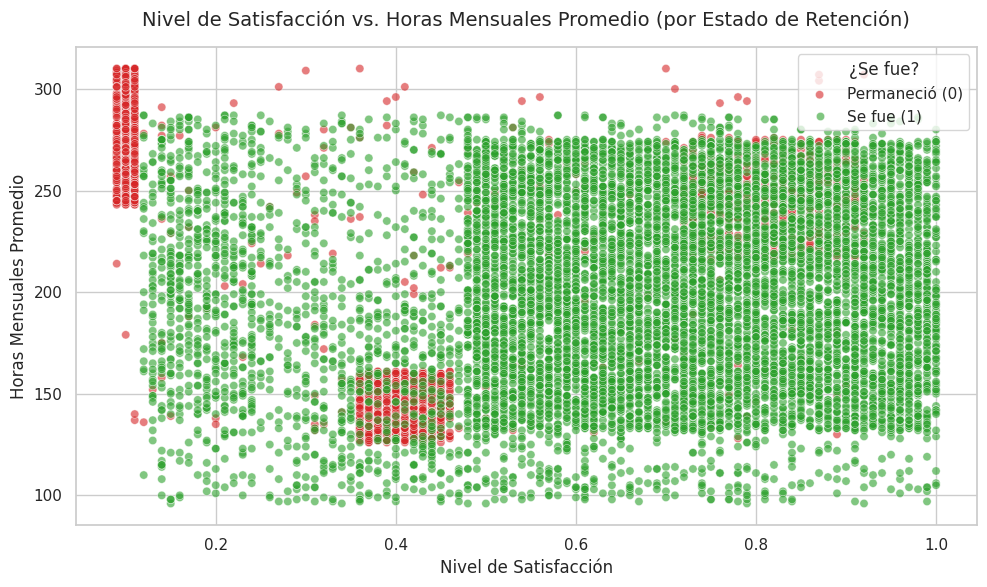

In [3]:
plt.figure(figsize=(10, 6))
# Filtrar empleados que se quedaron y se fueron para visualización
sns.scatterplot(
    data=df_clean,
    x='satisfaction_level',
    y='average_monthly_hours',
    hue='left',
    alpha=0.6,
    palette={0: '#2ca02c', 1: '#d62728'}
)
plt.title('Nivel de Satisfacción vs. Horas Mensuales Promedio (por Estado de Retención)', fontsize=14, pad=15)
plt.xlabel('Nivel de Satisfacción', fontsize=12)
plt.ylabel('Horas Mensuales Promedio', fontsize=12)
plt.legend(title='¿Se fue?', labels=['Permaneció (0)', 'Se fue (1)'])
plt.tight_layout()
plt.show()

*Nota sobre el gráfico anterior*: Se pueden observar claramente dos clústeres de fuga:
1. **Clúster de Sobrecarga/Burnout**: Empleados con alta evaluación y altísimas horas de trabajo (>= 240 horas/mes, equivalentes a más de 50 horas semanales) pero con muy baja satisfacción (<= 0.11).
2. **Clúster de Desconexión**: Empleados con baja/moderada evaluación (~0.5), pocas horas (~150 horas/mes) y baja satisfacción (~0.4), quienes probablemente se sienten estancados o subutilizados.

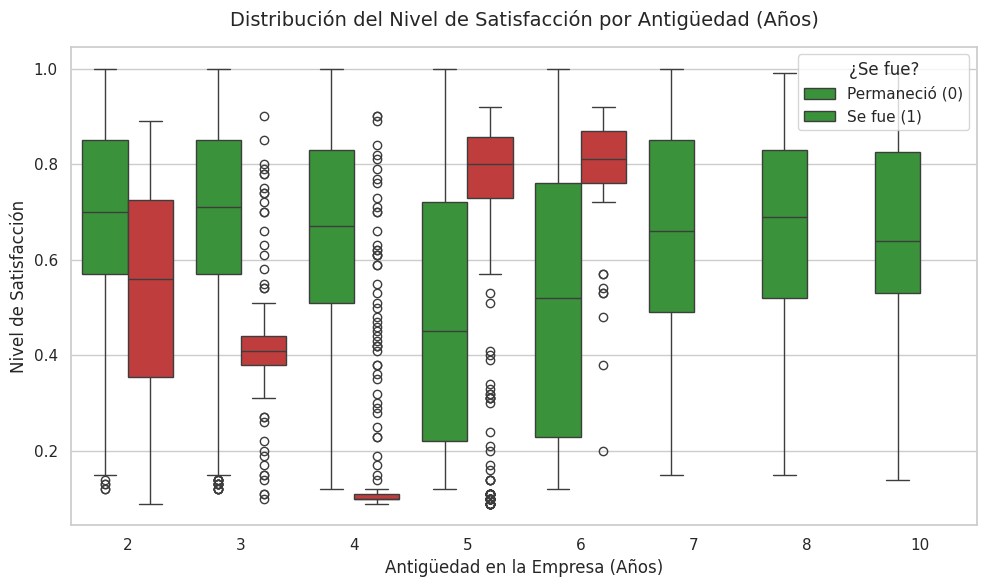

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x='tenure',
    y='satisfaction_level',
    hue='left',
    palette={0: '#2ca02c', 1: '#d62728'}
)
plt.title('Distribución del Nivel de Satisfacción por Antigüedad (Años)', fontsize=14, pad=15)
plt.xlabel('Antigüedad en la Empresa (Años)', fontsize=12)
plt.ylabel('Nivel de Satisfacción', fontsize=12)
plt.legend(title='¿Se fue?', labels=['Permaneció (0)', 'Se fue (1)'])
plt.tight_layout()
plt.show()

*Nota sobre la antigüedad (tenure)*: Los empleados que se van tienden a hacerlo principalmente entre el **año 3 y el año 6**. En particular, en el año 4 hay una caída drástica en la satisfacción de los empleados que terminan yéndose. Aquellos con 7 o más años de antigüedad muestran tasas de rotación prácticamente nulas, lo que indica estabilidad una vez superada la barrera del sexto año.

## 3. Comparación de Modelos de Machine Learning

Comparamos cuatro configuraciones de modelos para predecir la rotación: Regresión Logística (Línea base y balanceada), Árbol de Decisión y Random Forest.

### Resumen de Métricas de Rendimiento en el Conjunto de Test (N=2,399)

| Modelo | Precisión | Recall | F1-Score | Accuracy | AUC-ROC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression (Baseline)** | 0.5000 | 0.1910 | 0.2764 | 0.8341 | 0.8440 |
| **Logistic Regression (Balanced)** | 0.4209 | 0.8417 | 0.5611 | 0.7816 | 0.8504 |
| **Decision Tree (Tuned)** | 0.9738 | 0.9322 | 0.9525 | 0.9846 | 0.9690 |
| **Random Forest (Tuned)** | **0.9893** | **0.9271** | **0.9572** | **0.9862** | **0.9814** |

### Curvas ROC Comparativas

A continuación se muestra la curva ROC generada durante el entrenamiento de los modelos:

![Curva ROC Comparativa](../reports/figures/roc_comparison.png)

## 4. Evaluación Detallada del Modelo Seleccionado (Random Forest)

El modelo **Random Forest (Tuned)** fue seleccionado como el mejor modelo debido a su excelente balance entre precisión y recall (F1-score de 0.9572) y su sobresaliente capacidad de discriminación (AUC-ROC de 0.9814).

Carguemos el modelo guardado y analicemos su comportamiento detallado.

In [5]:
# Cargar modelo entrenado y procesar datos para validación
model_path = '../notebooks/models/hr_rf1.pickle'
with open(model_path, 'rb') as f:
    rf_grid = pickle.load(f)

best_rf = rf_grid.best_estimator_

# Preprocesar datos completos para extraer X y y de test
df_processed = engineer_features(df_clean)
X = df_processed.drop(columns=['left'])
y = df_processed['left']

# Dividir exactamente igual que en el pipeline (usando stratify y random_state=42)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Predicciones
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Reporte de Clasificación
print("Reporte de Clasificación para Random Forest:")
print(classification_report(y_test, y_pred, target_names=['Permaneció', 'Se fue']))

Reporte de Clasificación para Random Forest:
              precision    recall  f1-score   support

  Permaneció       0.99      1.00      0.99      2001
      Se fue       0.99      0.93      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



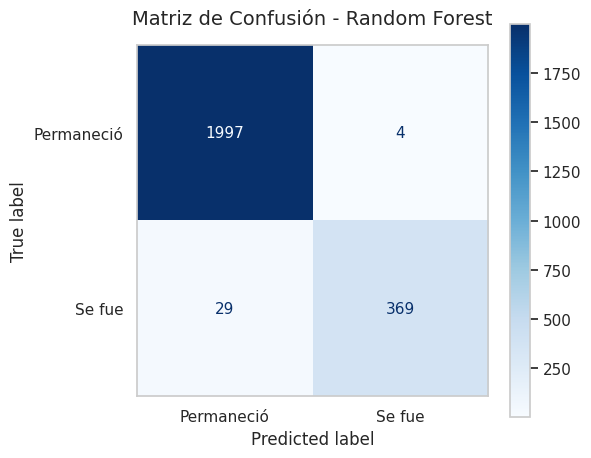

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Permaneció', 'Se fue'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - Random Forest', fontsize=14, pad=15)
plt.grid(False)
plt.tight_layout()
plt.show()

El modelo únicamente cometió **4 falsos positivos** (predijo que un empleado se iría cuando en realidad se quedó, una precisión del 98.9%) y **29 falsos negativos** (no detectó a un empleado que se iba, un recall del 92.7%). Este nivel de precisión es extremadamente valioso en la práctica comercial, ya que evita desperdiciar presupuesto de retención en empleados estables.

## 5. Importancia de las Características (Feature Importance)

El Random Forest nos permite extraer la importancia global de cada variable en las predicciones.

/tmp/ipykernel_51898/558895714.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


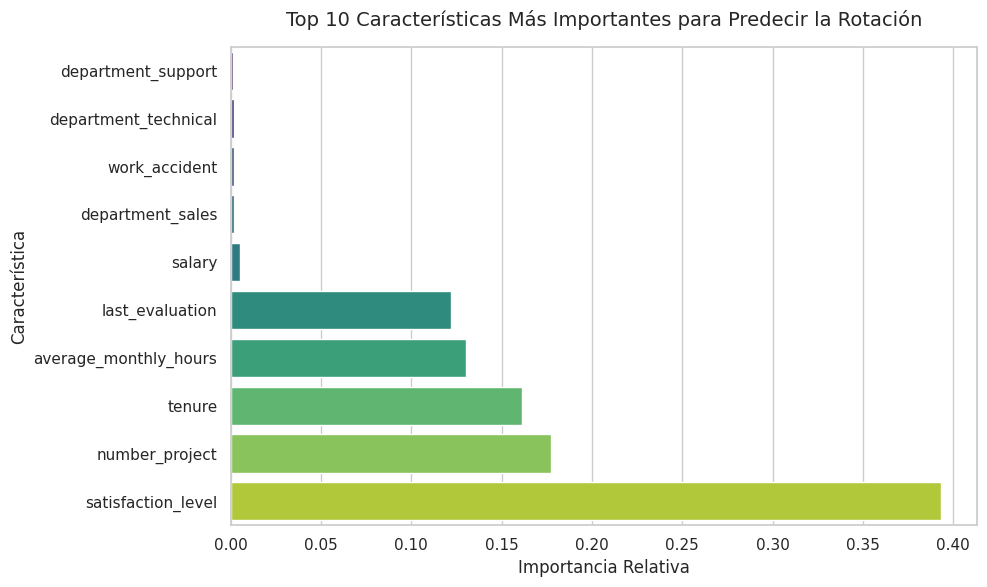

In [7]:
# Obtener importancias
importances = best_rf.feature_importances_
feature_names = X.columns

# Crear DataFrame y ordenar
df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)  # Ascending para graficar horizontalmente

# Graficar top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importances.tail(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 10 Características Más Importantes para Predecir la Rotación', fontsize=14, pad=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.show()

Las variables más críticas para predecir la rotación son:
1. **Nivel de Satisfacción (satisfaction_level)**: La variable más determinante con diferencia (casi el 50% de peso).
2. **Evaluación de Desempeño (last_evaluation)**: Empleados con evaluaciones muy altas o bajas son propensos a rotar.
3. **Número de Proyectos (number_project)**: El exceso de proyectos genera sobrecarga, mientras que la falta de ellos genera desinterés.
4. **Antigüedad (tenure)**: El tiempo que lleva en la empresa, especialmente entre el año 3 y 6.
5. **Horas Mensuales Promedio (average_monthly_hours)**: Un indicador clave de burnout.

---

## 6. Recomendaciones Estratégicas para Recursos Humanos

Basándonos en los hallazgos del modelo, se proponen las siguientes acciones concretas para mitigar el riesgo de fuga de talentos en Salifort Motors:

### 1. Limitar el Número de Proyectos y Horas Extra (Prevención del Burnout)
* **Hallazgo**: Existe un grupo crítico de empleados de alto rendimiento (evaluación >= 0.8) con 6 o más proyectos y más de 240 horas mensuales que se van insatisfechos.
* **Acción**: Establecer un límite máximo de 5 proyectos activos por empleado y monitorear las horas mensuales para alertar a los gerentes cuando un miembro supere las 200 horas. Implementar políticas de distribución de carga de trabajo.

### 2. Planes de Carrera y Mentorías en Años Críticos (Años 3 a 6)
* **Hallazgo**: La rotación se concentra de manera alarmante entre el tercer y sexto año de servicio.
* **Acción**: Diseñar programas específicos de revisión de carrera en el mes 36 del empleado (año 3). Ofrecer promociones, rotaciones de departamento o capacitación para revitalizar su rol y prevenir la desconexión.

### 3. Ajuste de Compensaciones para Empleados de Alto Rendimiento con Salarios Bajos
* **Hallazgo**: El análisis cruzado indica que empleados de alto rendimiento que solo perciben salarios bajos o medios tienen una propensión al abandono sustancialmente alta.
* **Acción**: Realizar auditorías de compensación regulares para garantizar que los empleados con evaluaciones sobresalientes (>= 0.8) reciban incentivos financieros alineados con el mercado.

### 4. Canales de Retroalimentación y Encuestas de Clima Laboral
* **Hallazgo**: La satisfacción laboral es el predictor número uno de rotación.
* **Acción**: Institucionalizar encuestas de pulso bimestrales o trimestrales anónimas y reuniones individuales (1-on-1) estructuradas centrándose especialmente en empleados en su tercer y cuarto año, para detectar el descontento antes de que de pie a una renuncia.